# 🩺 Diabetes Prediction — KNN Classification
### CSE 382: Data Mining and Business Intelligence — Summer 2026

---

| | |
|---|---|
| **Algorithm** | K-Nearest Neighbors (KNN) |
| **Dataset** | Diabetes Prediction — 1000 patients, 11 features |
| **Target** | CLASS: N = Not Diabetic · P = Pre-Diabetic · Y = Diabetic |
| **Final Model** | K = 2 · Euclidean Distance · SMOTE-balanced training |

---


## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import f_oneway
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from imblearn.over_sampling import SMOTE

sns.set_theme(style="whitegrid", palette="viridis")
print("✅ Libraries loaded")


✅ Libraries loaded


## 2. Load Dataset

In [3]:
dataset = pd.read_csv('C:/Users/Ahmed/Downloads/New folder (2)/Dataset of Diabetes .csv')
print(f"Shape  : {dataset.shape}")
print(f"Columns: {dataset.columns.tolist()}")
dataset.head()


Shape  : (1000, 14)
Columns: ['ID', 'No_Pation', 'Gender', 'AGE', 'Urea', 'Cr', 'HbA1c', 'Chol', 'TG', 'HDL', 'LDL', 'VLDL', 'BMI', 'CLASS']


,ID,No_Pation,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,502,17975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,735,34221,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,420,47975,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,680,87656,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,504,34223,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


In [4]:
print("Data Types & Missing Values")
print(dataset.dtypes)
print("\nMissing values:", dataset.isnull().sum().sum())
print("\nCLASS distribution:")
print(dataset['CLASS'].value_counts())


Data Types & Missing Values
ID             int64
No_Pation      int64
Gender        object
AGE            int64
Urea         float64
Cr             int64
HbA1c        float64
Chol         float64
TG           float64
HDL          float64
LDL          float64
VLDL         float64
BMI          float64
CLASS         object
dtype: object

Missing values: 0

CLASS distribution:
CLASS
Y     840
N     102
P      53
Y       4
N       1
Name: count, dtype: int64


## 3. Data Cleaning

- Strip trailing whitespace from `CLASS` (`"Y "` → `"Y"`) and `Gender` (`"f"` → `"F"`)
- Drop non-predictive ID columns: `ID`, `No_Pation`


In [5]:
dataset["CLASS"]  = dataset["CLASS"].str.strip()
dataset["Gender"] = dataset["Gender"].str.strip().str.upper()
dataset           = dataset.drop(columns=["ID", "No_Pation"])

print(f"CLASS  values : {sorted(dataset['CLASS'].unique())}")
print(f"Gender values : {sorted(dataset['Gender'].unique())}")
print(f"Shape after cleaning: {dataset.shape}")
dataset.head()


CLASS  values : ['N', 'P', 'Y']
Gender values : ['F', 'M']
Shape after cleaning: (1000, 12)


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
1,M,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,N
2,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
3,F,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,N
4,M,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,N


## 4. Label Encoding

| Column | Mapping |
|---|---|
| Gender | F = 0, M = 1 |
| CLASS  | N = 0, P = 1, Y = 2 |


In [6]:
dataset['Gender'] = dataset['Gender'].astype('category').cat.codes   # F=0, M=1
dataset['CLASS']  = dataset['CLASS'].astype('category').cat.codes    # N=0, P=1, Y=2

print("CLASS distribution after encoding:")
print(dataset['CLASS'].value_counts().rename({0:'N (Not Diabetic)',1:'P (Pre-Diabetic)',2:'Y (Diabetic)'}))
dataset.head()


CLASS distribution after encoding:
CLASS
Y (Diabetic)        844
N (Not Diabetic)    103
P (Pre-Diabetic)     53
Name: count, dtype: int64


,Gender,AGE,Urea,Cr,HbA1c,Chol,TG,HDL,LDL,VLDL,BMI,CLASS
0,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
1,1,26,4.5,62,4.9,3.7,1.4,1.1,2.1,0.6,23.0,0
2,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
3,0,50,4.7,46,4.9,4.2,0.9,2.4,1.4,0.5,24.0,0
4,1,33,7.1,46,4.9,4.9,1.0,0.8,2.0,0.4,21.0,0


## 5. Outlier Detection & Removal — IQR Method

**Formula:** Lower = Q1 − 1.5×IQR · Upper = Q3 + 1.5×IQR  
Rows outside bounds are removed cumulatively across all features.


In [7]:
numerical_cols = ["AGE","Urea","Cr","HbA1c","Chol","TG","HDL","LDL","VLDL","BMI"]
cleaned = dataset.copy()

print(f"{'Feature':<8} | {'Lower':>8} {'Upper':>8} | {'Outliers':>9}")
print("-" * 42)
for col in numerical_cols:
    Q1, Q3 = cleaned[col].quantile(0.25), cleaned[col].quantile(0.75)
    IQR    = Q3 - Q1
    lo, hi = Q1 - 1.5*IQR, Q3 + 1.5*IQR
    n_out  = ((cleaned[col] < lo) | (cleaned[col] > hi)).sum()
    print(f"{col:<8} | {lo:>8.2f} {hi:>8.2f} | {n_out:>9}")
    cleaned = cleaned[(cleaned[col] >= lo) & (cleaned[col] <= hi)]

dataset = cleaned.copy()
print(f"\nRows before: 1000  →  after: {dataset.shape[0]}  (removed {1000-dataset.shape[0]})")


Feature  |    Lower    Upper |  Outliers
------------------------------------------
AGE      |    39.00    71.00 |        98
Urea     |     0.70     8.70 |        59
Cr       |     8.50   108.50 |        10
HbA1c    |     1.55    15.55 |         6
Chol     |     1.60     8.00 |        24
TG       |    -0.60     5.00 |        40
HDL      |     0.30     1.90 |        40
LDL      |    -0.45     5.55 |         3
VLDL     |    -0.35     2.45 |        42
BMI      |    15.50    43.50 |         0

Rows before: 1000  →  after: 678  (removed 322)


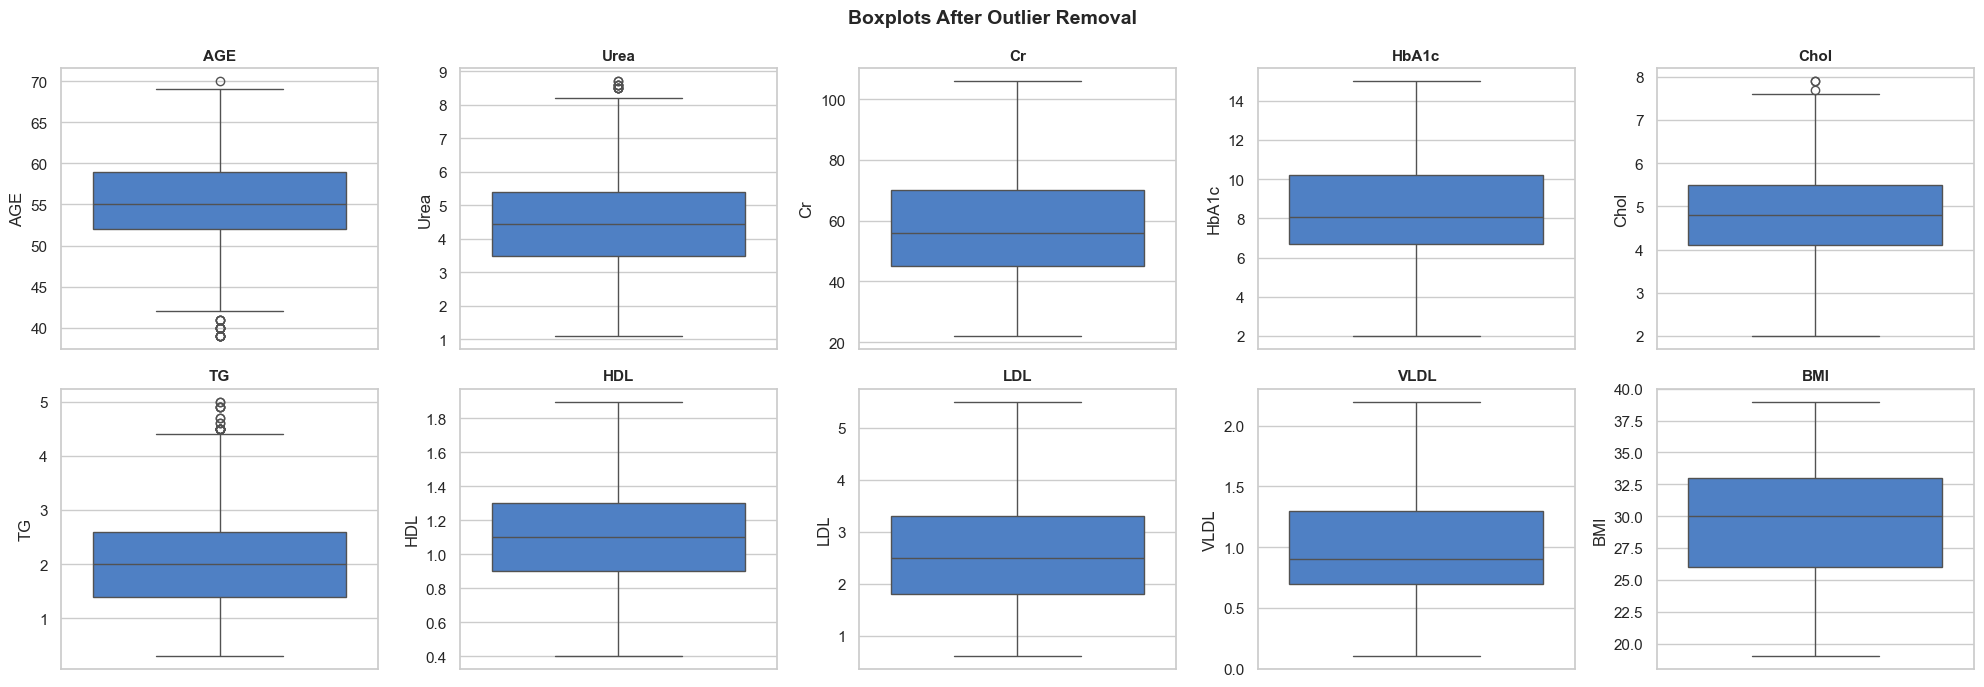

In [8]:
fig, axes = plt.subplots(2, 5, figsize=(20, 7))
for ax, col in zip(axes.flatten(), numerical_cols):
    sns.boxplot(y=dataset[col], ax=ax, color="#3b7dd8")
    ax.set_title(col, fontsize=11, fontweight='bold')
fig.suptitle("Boxplots After Outlier Removal", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


## 6. Skewness Correction — log1p Transform

Features `Urea, Cr, TG, VLDL, HDL, LDL` are right-skewed.  
Applied `log(1 + x)` to normalize their distributions.


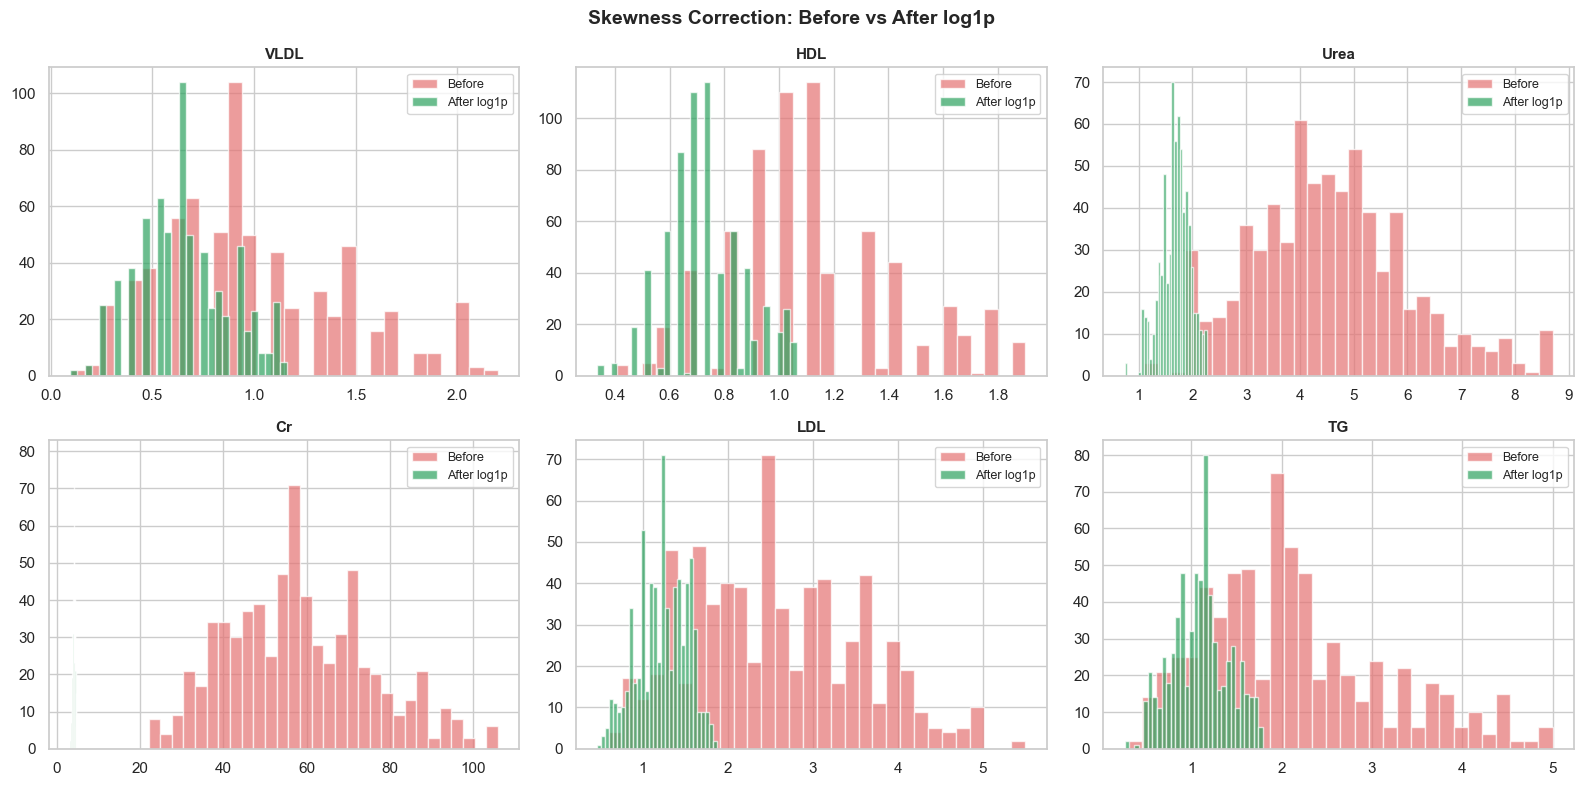

✅ log1p applied to: ['VLDL', 'HDL', 'Urea', 'Cr', 'LDL', 'TG']


In [9]:
skewed_cols = ["VLDL","HDL","Urea","Cr","LDL","TG"]

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flatten(), skewed_cols):
    ax.hist(dataset[col], bins=30, color="#e57373", edgecolor='white', alpha=0.7, label='Before')
    after = np.log1p(dataset[col])
    ax.hist(after, bins=30, color="#2ca25f", edgecolor='white', alpha=0.7, label='After log1p')
    ax.set_title(col, fontsize=11, fontweight='bold')
    ax.legend(fontsize=9)
fig.suptitle("Skewness Correction: Before vs After log1p", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

for col in skewed_cols:
    dataset[col] = np.log1p(dataset[col])
print("✅ log1p applied to:", skewed_cols)


## 7. ANOVA — Feature Significance Test

Tests whether each feature differs significantly across the 3 diabetes classes.  
**p-value < 0.05** → feature is statistically useful for classification.


In [10]:
g0 = dataset[dataset["CLASS"]==0]
g1 = dataset[dataset["CLASS"]==1]
g2 = dataset[dataset["CLASS"]==2]

anova_cols = ["AGE","Urea","Cr","HbA1c","Chol","TG","HDL","LDL","VLDL","BMI","Gender"]
sig, non_sig = [], []

print(f"{'Feature':<10} {'F-stat':>10} {'p-value':>12}  Result")
print("-" * 48)
for col in anova_cols:
    f, p = f_oneway(g0[col], g1[col], g2[col])
    mark = "✅ Significant" if p < 0.05 else "❌ Not significant"
    print(f"{col:<10} {f:>10.3f} {p:>12.4f}  {mark}")
    (sig if p < 0.05 else non_sig).append(col)

print(f"\n→ Significant features  : {sig}")
print(f"→ Non-significant features: {non_sig}")


Feature        F-stat      p-value  Result
------------------------------------------------
AGE           137.593       0.0000  ✅ Significant
Urea            0.856       0.4253  ❌ Not significant
Cr              0.463       0.6297  ❌ Not significant
HbA1c         124.742       0.0000  ✅ Significant
Chol            8.694       0.0002  ✅ Significant
TG             20.244       0.0000  ✅ Significant
HDL             0.887       0.4122  ❌ Not significant
LDL             0.940       0.3911  ❌ Not significant
VLDL           12.024       0.0000  ✅ Significant
BMI           161.916       0.0000  ✅ Significant
Gender          4.831       0.0083  ✅ Significant

→ Significant features  : ['AGE', 'HbA1c', 'Chol', 'TG', 'VLDL', 'BMI', 'Gender']
→ Non-significant features: ['Urea', 'Cr', 'HDL', 'LDL']


## 8. Correlation Heatmap

Checks multicollinearity between features.  
Notable: **Urea ↔ Cr** show moderate correlation.


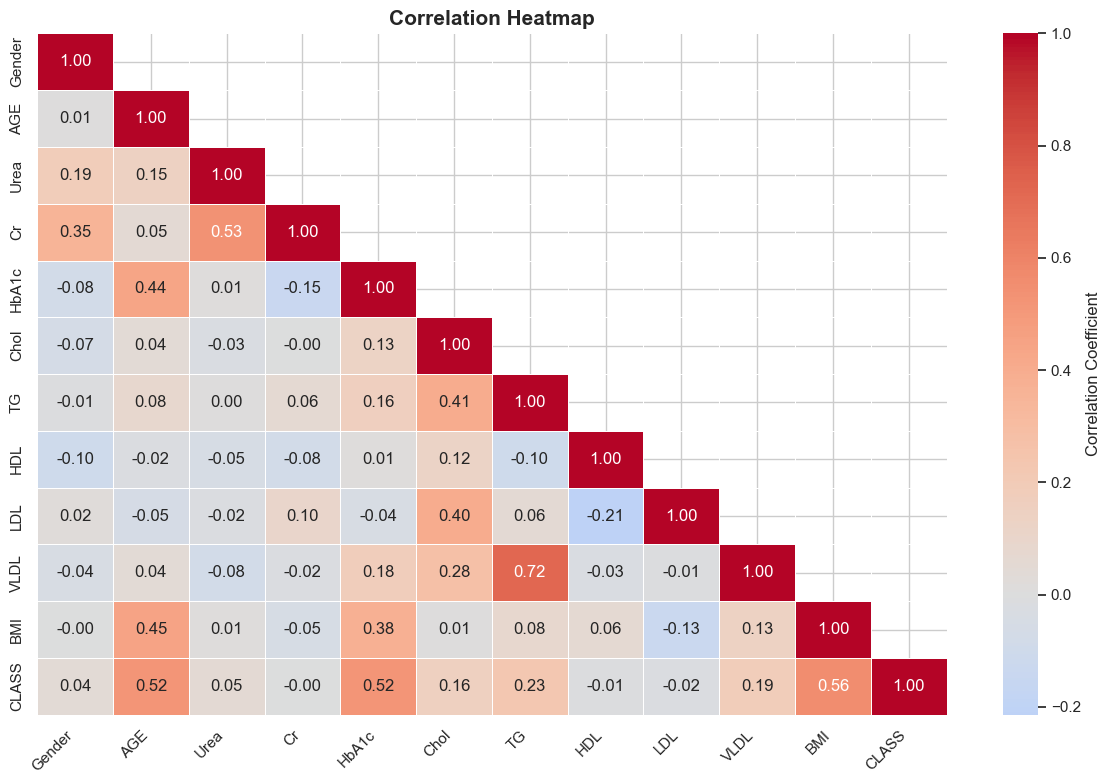

In [11]:
corr = dataset.corr()
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

plt.figure(figsize=(12, 8))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, linewidths=0.5, linecolor="white",
            cbar_kws={"label": "Correlation Coefficient"})
plt.title("Correlation Heatmap", fontsize=15, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


## 9. Train / Test Split & Feature Scaling

- **Split:** 70% train / 30% test (stratified to preserve class ratios)
- **StandardScaler** fitted on training set only — prevents data leakage


In [12]:
X = dataset.drop(columns=['CLASS'])
y = dataset['CLASS']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, shuffle=True, random_state=42, stratify=y
)
print(f"Train : {X_train.shape[0]} samples | Test: {X_test.shape[0]} samples")

cols_to_scale = ["AGE","Urea","Cr","HbA1c","Chol","TG","HDL","LDL","VLDL","BMI"]
scaler = StandardScaler()
scaler.fit(X_train[cols_to_scale])

X_train_f = X_train.copy();  X_test_f = X_test.copy()
X_train_f[cols_to_scale] = scaler.transform(X_train[cols_to_scale])
X_test_f[cols_to_scale]  = scaler.transform(X_test[cols_to_scale])
print("✅ StandardScaler applied")


Train : 474 samples | Test: 204 samples
✅ StandardScaler applied


## 10. Handle Class Imbalance — SMOTE

The dataset is severely imbalanced: ~84% Diabetic, ~10% Not Diabetic, ~5% Pre-Diabetic.  
**SMOTE** generates synthetic minority samples on the training set only.


In [13]:
print("Before SMOTE — train distribution:")
print(y_train.value_counts().rename({0:'N',1:'P',2:'Y'}))

sm = SMOTE(random_state=42)
X_train_s, y_train_s = sm.fit_resample(X_train_f, y_train)

print(f"\nAfter SMOTE — train distribution:")
print(pd.Series(y_train_s).value_counts().rename({0:'N',1:'P',2:'Y'}))
print(f"\nNew training shape: {X_train_s.shape}")


Before SMOTE — train distribution:
CLASS
Y    410
N     39
P     25
Name: count, dtype: int64

After SMOTE — train distribution:
CLASS
Y    410
P    410
N    410
Name: count, dtype: int64

New training shape: (1230, 11)


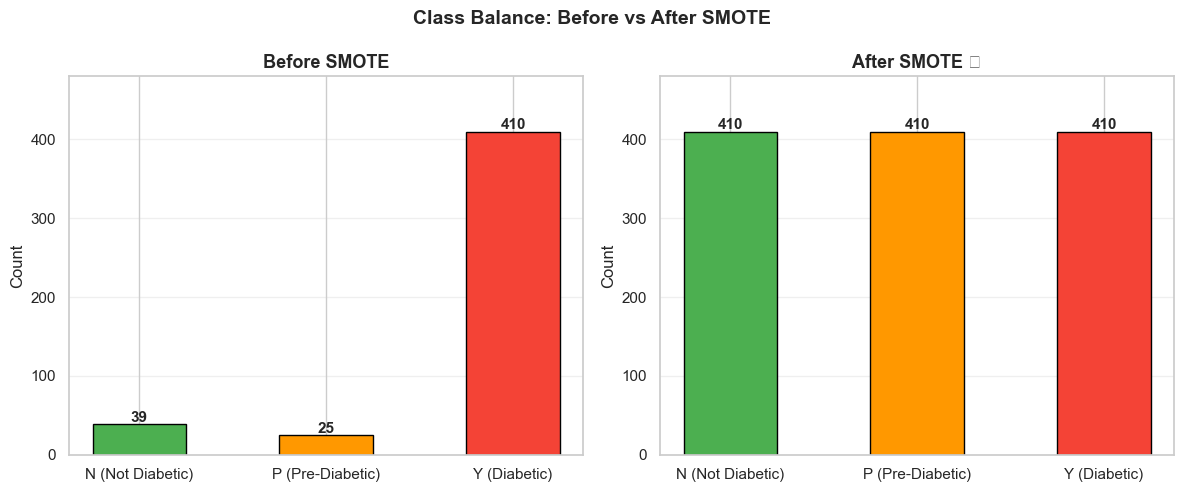

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
labels = ['N (Not Diabetic)', 'P (Pre-Diabetic)', 'Y (Diabetic)']
colors = ['#4CAF50', '#FF9800', '#F44336']
before = y_train.value_counts().sort_index()
after  = pd.Series(y_train_s).value_counts().sort_index()

for ax, vals, title in zip(axes, [before, after], ['Before SMOTE', 'After SMOTE ✅']):
    bars = ax.bar(labels, vals.values, color=colors, edgecolor='black', width=0.5)
    for bar, v in zip(bars, vals.values):
        ax.text(bar.get_x()+bar.get_width()/2, v+3, str(v),
                ha='center', fontweight='bold', fontsize=11)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.set_ylabel('Count'); ax.grid(axis='y', alpha=0.3); ax.set_ylim(0, 480)

fig.suptitle('Class Balance: Before vs After SMOTE', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


## 11. Finding Optimal K & Overfitting Analysis

We test K = 1 to 20 and track **Train Accuracy**, **Test Accuracy**, and the **Overfitting Gap** (Train − Test).

> **K=1** memorizes the training data → Train = 100%, Gap = 6.37% ❌  
> **K=2** generalizes better → Train = 98.46%, Gap = 5.32% ✅


In [15]:
k_range   = range(1, 21)
train_acc = []; test_acc = []; cv_acc = []; gap_list = []
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_range:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_s, y_train_s)
    tr = accuracy_score(y_train_s, knn.predict(X_train_s))
    te = accuracy_score(y_test,    knn.predict(X_test_f))
    cv = cross_val_score(knn, X_train_s, y_train_s, cv=skf).mean()
    train_acc.append(tr); test_acc.append(te)
    cv_acc.append(cv);    gap_list.append(tr - te)

print(f"{'K':>3} | {'Train':>8} | {'Test':>8} | {'CV':>8} | {'Gap':>7} | Status")
print("-" * 58)
for i, k in enumerate(k_range):
    st = '✅ OK' if gap_list[i] <= 0.055 else '❌ Overfit'
    print(f"{k:>3} | {train_acc[i]*100:>7.2f}% | {test_acc[i]*100:>7.2f}% | "
          f"{cv_acc[i]*100:>7.2f}% | {gap_list[i]*100:>6.2f}% | {st}")

BEST_K = 2
print(f"\n→ Selected K = {BEST_K}  (lowest gap while keeping highest test accuracy)")


  K |    Train |     Test |       CV |     Gap | Status
----------------------------------------------------------
  1 |  100.00% |   93.63% |   98.29% |   6.37% | ❌ Overfit
  2 |   98.46% |   93.14% |   97.97% |   5.32% | ✅ OK
  3 |   98.54% |   93.14% |   98.13% |   5.40% | ✅ OK
  4 |   98.21% |   92.16% |   97.32% |   6.05% | ❌ Overfit
  5 |   98.21% |   92.16% |   97.40% |   6.05% | ❌ Overfit
  6 |   97.97% |   91.18% |   96.75% |   6.79% | ❌ Overfit
  7 |   98.05% |   91.18% |   96.75% |   6.87% | ❌ Overfit
  8 |   97.56% |   90.20% |   96.02% |   7.36% | ❌ Overfit
  9 |   97.64% |   90.20% |   96.02% |   7.45% | ❌ Overfit
 10 |   96.83% |   89.71% |   95.53% |   7.12% | ❌ Overfit
 11 |   96.91% |   89.71% |   95.45% |   7.20% | ❌ Overfit
 12 |   96.75% |   90.20% |   95.28% |   6.55% | ❌ Overfit
 13 |   96.50% |   90.20% |   95.28% |   6.31% | ❌ Overfit
 14 |   96.18% |   90.20% |   94.55% |   5.98% | ❌ Overfit
 15 |   96.18% |   90.20% |   94.63% |   5.98% | ❌ Overfit
 16 |   95

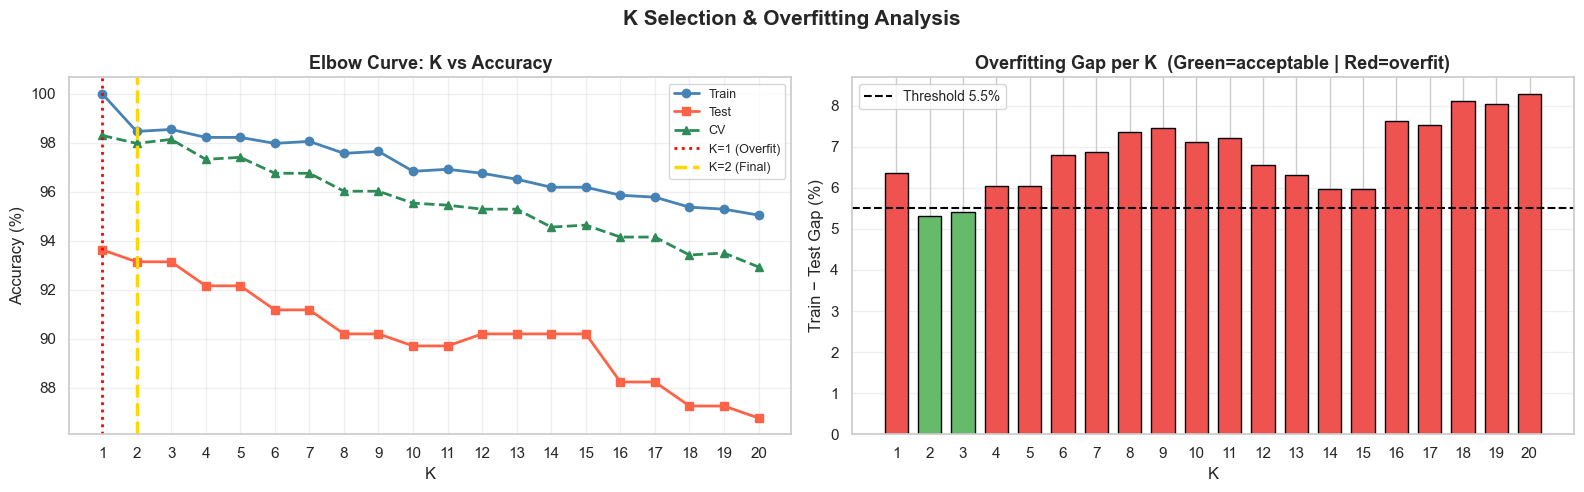

In [16]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Elbow curve
axes[0].plot(k_range, [a*100 for a in train_acc], 'o-', color='steelblue', label='Train', lw=2)
axes[0].plot(k_range, [a*100 for a in test_acc],  's-', color='tomato',    label='Test',  lw=2)
axes[0].plot(k_range, [a*100 for a in cv_acc],    '^--',color='seagreen',  label='CV',    lw=2)
axes[0].axvline(1, color='red',  linestyle=':',  lw=2,   label='K=1 (Overfit)')
axes[0].axvline(2, color='gold', linestyle='--', lw=2.5, label='K=2 (Final)')
axes[0].set_xlabel('K'); axes[0].set_ylabel('Accuracy (%)')
axes[0].set_title('Elbow Curve: K vs Accuracy', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True, alpha=0.3); axes[0].set_xticks(list(k_range))

# Gap bar
bar_colors = ['#66BB6A' if g <= 0.055 else '#EF5350' for g in gap_list]
axes[1].bar(list(k_range), [g*100 for g in gap_list], color=bar_colors, edgecolor='black', width=0.7)
axes[1].axhline(5.5, color='black', linestyle='--', lw=1.5, label='Threshold 5.5%')
axes[1].set_xlabel('K'); axes[1].set_ylabel('Train − Test Gap (%)')
axes[1].set_title('Overfitting Gap per K  (Green=acceptable | Red=overfit)',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10); axes[1].grid(axis='y', alpha=0.3); axes[1].set_xticks(list(k_range))

plt.suptitle('K Selection & Overfitting Analysis', fontsize=15, fontweight='bold')
plt.tight_layout(); plt.show()


## 12. Train Final Model (K = 2)

In [17]:
knn_final = KNeighborsClassifier(n_neighbors=BEST_K)
knn_final.fit(X_train_s, y_train_s)

y_pred     = knn_final.predict(X_test_f)
train_final = accuracy_score(y_train_s, knn_final.predict(X_train_s))
test_final  = accuracy_score(y_test, y_pred)
cv_scores   = cross_val_score(knn_final, X_train_s, y_train_s, cv=skf)

print("=" * 52)
print("      BEFORE vs AFTER OVERFITTING FIX")
print("=" * 52)
print(f"{'Metric':<20} {'K=1 (Before)':>14} {'K=2 (After)':>14}")
print("-" * 52)
print(f"{'Train Accuracy':<20} {'100.00%':>14} {train_final*100:>13.2f}%")
print(f"{'Test Accuracy':<20} {'93.63%':>14} {test_final*100:>13.2f}%")
print(f"{'CV Mean (5-Fold)':<20} {'98.29%':>14} {cv_scores.mean()*100:>13.2f}%")
print(f"{'Overfit Gap':<20} {'6.37%':>14} {(train_final-test_final)*100:>13.2f}%")
print("=" * 52)


      BEFORE vs AFTER OVERFITTING FIX
Metric                 K=1 (Before)    K=2 (After)
----------------------------------------------------
Train Accuracy              100.00%         98.46%
Test Accuracy                93.63%         93.14%
CV Mean (5-Fold)             98.29%         97.97%
Overfit Gap                   6.37%          5.32%


## 13. Model Evaluation

In [18]:
print("Classification Report (K=2):")
print(classification_report(y_test, y_pred,
      target_names=['N (Not Diabetic)', 'P (Pre-Diabetic)', 'Y (Diabetic)']))


Classification Report (K=2):
                  precision    recall  f1-score   support

N (Not Diabetic)       0.81      0.76      0.79        17
P (Pre-Diabetic)       0.50      0.45      0.48        11
    Y (Diabetic)       0.97      0.98      0.97       176

        accuracy                           0.93       204
       macro avg       0.76      0.73      0.75       204
    weighted avg       0.93      0.93      0.93       204



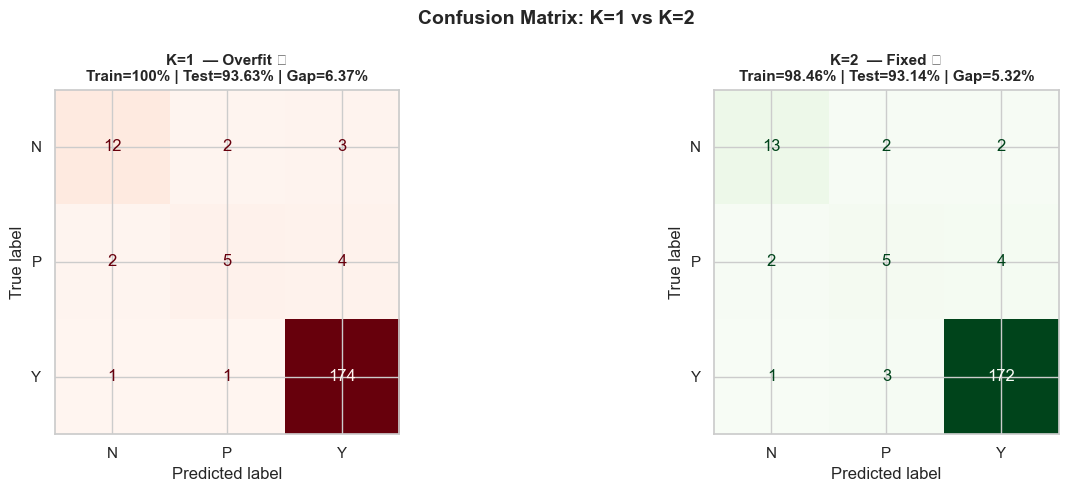

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Confusion matrices: K=1 vs K=2
knn_k1   = KNeighborsClassifier(n_neighbors=1).fit(X_train_s, y_train_s)
y_pred_k1 = knn_k1.predict(X_test_f)

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_k1),
    display_labels=['N','P','Y']).plot(ax=axes[0], colorbar=False, cmap='Reds')
axes[0].set_title('K=1  — Overfit ❌\nTrain=100% | Test=93.63% | Gap=6.37%',
                  fontsize=11, fontweight='bold')

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred),
    display_labels=['N','P','Y']).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'K=2  — Fixed ✅\nTrain=98.46% | Test=93.14% | Gap=5.32%',
                  fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix: K=1 vs K=2', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


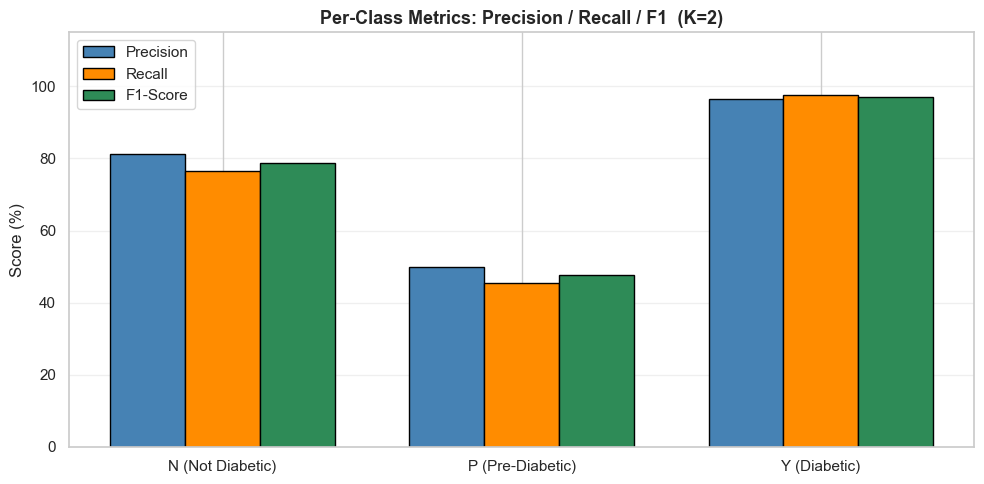

In [20]:
# Per-class metrics bar chart
r = classification_report(y_test, y_pred, target_names=['N','P','Y'], output_dict=True)
classes = ['N','P','Y']
x = np.arange(3); w = 0.25

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(x-w, [r[c]['precision']*100 for c in classes], w, label='Precision', color='steelblue',  edgecolor='black')
ax.bar(x,   [r[c]['recall']*100    for c in classes], w, label='Recall',    color='darkorange', edgecolor='black')
ax.bar(x+w, [r[c]['f1-score']*100  for c in classes], w, label='F1-Score',  color='seagreen',   edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(['N (Not Diabetic)', 'P (Pre-Diabetic)', 'Y (Diabetic)'], fontsize=11)
ax.set_ylabel('Score (%)'); ax.set_ylim(0, 115)
ax.set_title('Per-Class Metrics: Precision / Recall / F1  (K=2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


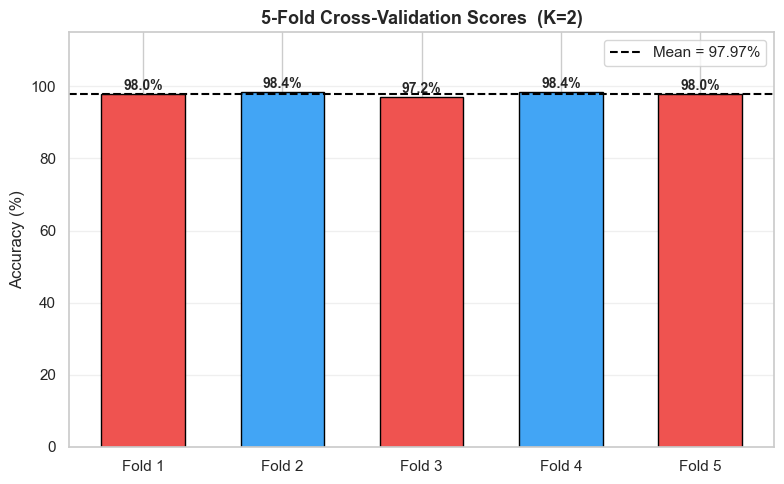

In [21]:
# 5-Fold CV bars
fig, ax = plt.subplots(figsize=(8, 5))
bar_colors = ['#42A5F5' if s >= cv_scores.mean() else '#EF5350' for s in cv_scores]
bars = ax.bar([f'Fold {i+1}' for i in range(5)], cv_scores*100, color=bar_colors, edgecolor='black', width=0.6)
ax.axhline(cv_scores.mean()*100, color='black', linestyle='--', lw=1.5,
           label=f'Mean = {cv_scores.mean()*100:.2f}%')
for bar, v in zip(bars, cv_scores):
    ax.text(bar.get_x()+bar.get_width()/2, v*100+0.3, f'{v*100:.1f}%',
            ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Accuracy (%)'); ax.set_ylim(0, 115)
ax.set_title('5-Fold Cross-Validation Scores  (K=2)', fontsize=13, fontweight='bold')
ax.legend(fontsize=11); ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


## 14. Feature Importance

Measured by the spread of class means across N / P / Y groups.  
Higher spread = better class separation = more important feature.


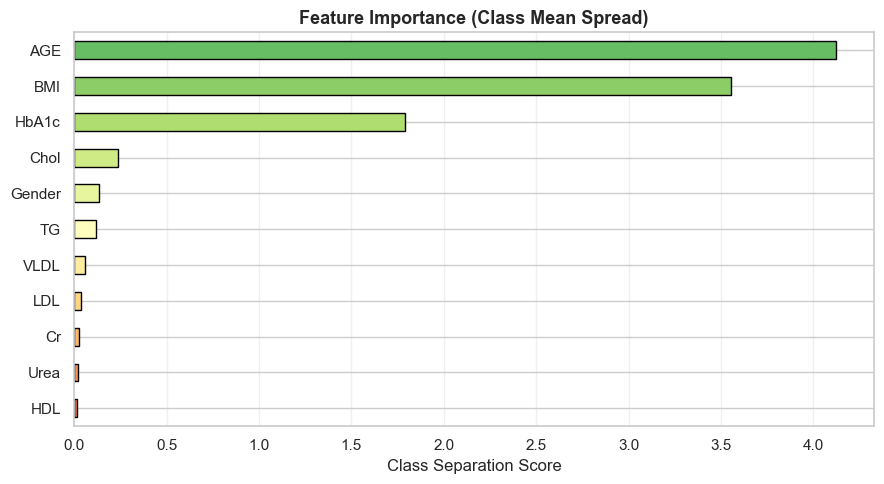

Top 3 Features:
  AGE: 4.1225
  BMI: 3.5528
  HbA1c: 1.7923


In [22]:
feat_names = X.columns.tolist()
importance = [np.std([dataset[dataset['CLASS']==c][f].mean()
                      for c in dataset['CLASS'].unique()])
              for f in feat_names]

feat_imp   = pd.Series(importance, index=feat_names).sort_values()
bar_colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feat_imp)))

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color=bar_colors, edgecolor='black')
plt.xlabel('Class Separation Score', fontsize=12)
plt.title('Feature Importance (Class Mean Spread)', fontsize=13, fontweight='bold')
plt.grid(axis='x', alpha=0.3); plt.tight_layout(); plt.show()

print("Top 3 Features:")
for name, val in feat_imp.sort_values(ascending=False).head(3).items():
    print(f"  {name}: {val:.4f}")


## 15. Final Summary

       FINAL MODEL SUMMARY — KNN CLASSIFIER
  Algorithm          : K-Nearest Neighbors (KNN)
  Final K            : 2  (selected to minimize overfitting)
  Distance Metric    : Euclidean (Minkowski p=2)
  Features           : 11
  Training Samples   : 1230  (after SMOTE)
  Test Samples       : 204
  Train Accuracy     : 98.46%
  Test  Accuracy     : 93.14%
  Overfitting Gap    : 5.32%  ✅
  CV Mean (5-Fold)   : 97.97%
  CV Std             : 0.45%


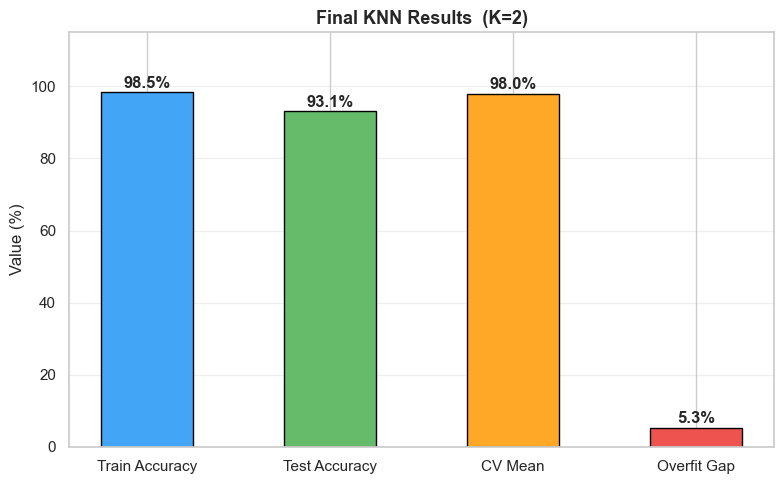

In [23]:
print("=" * 58)
print("       FINAL MODEL SUMMARY — KNN CLASSIFIER")
print("=" * 58)
print(f"  Algorithm          : K-Nearest Neighbors (KNN)")
print(f"  Final K            : {BEST_K}  (selected to minimize overfitting)")
print(f"  Distance Metric    : Euclidean (Minkowski p=2)")
print(f"  Features           : {X.shape[1]}")
print(f"  Training Samples   : {X_train_s.shape[0]}  (after SMOTE)")
print(f"  Test Samples       : {X_test_f.shape[0]}")
print(f"  Train Accuracy     : {train_final*100:.2f}%")
print(f"  Test  Accuracy     : {test_final*100:.2f}%")
print(f"  Overfitting Gap    : {(train_final-test_final)*100:.2f}%  ✅")
print(f"  CV Mean (5-Fold)   : {cv_scores.mean()*100:.2f}%")
print(f"  CV Std             : {cv_scores.std()*100:.2f}%")
print("=" * 58)

fig, ax = plt.subplots(figsize=(8, 5))
metrics = ['Train Accuracy', 'Test Accuracy', 'CV Mean', 'Overfit Gap']
values  = [train_final*100, test_final*100, cv_scores.mean()*100, (train_final-test_final)*100]
colors  = ['#42A5F5', '#66BB6A', '#FFA726', '#EF5350']
bars    = ax.bar(metrics, values, color=colors, edgecolor='black', width=0.5)
for bar, v in zip(bars, values):
    ax.text(bar.get_x()+bar.get_width()/2, v+0.4, f'{v:.1f}%',
            ha='center', va='bottom', fontsize=12, fontweight='bold')
ax.set_ylabel('Value (%)'); ax.set_ylim(0, 115)
ax.set_title(f'Final KNN Results  (K={BEST_K})', fontsize=13, fontweight='bold')
ax.grid(axis='y', alpha=0.3); plt.tight_layout(); plt.show()
